## Wake data visualizations

https://github.com/garrettj403/SciencePlots

https://matplotlib.org/stable/gallery/index.html

In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import RegularGridInterpolator

### Loading the data over line:
Each *.csv file is a line extracted from a surface at hub height ($y=0.65H$). z141065 refers to the line at: $z=14.1065H$.

In [192]:
z141065 = pd.read_csv('./line/z141065.csv')
z258756 = pd.read_csv('./line/z258756.csv')
z1802953 = pd.read_csv('./line/z1802953.csv')
z21952565 = pd.read_csv('./line/z21952565.csv')

x11964 = pd.read_csv('./line/x11964.csv')
x12589 = pd.read_csv('./line/x12589.csv')
x13214 = pd.read_csv('./line/x13214.csv')
x13708 = pd.read_csv('./line/x13708.csv')
x14333 = pd.read_csv('./line/x14333.csv')
x14958 = pd.read_csv('./line/x14958.csv')
x15443 = pd.read_csv('./line/x15443.csv')
x16068 = pd.read_csv('./line/x16068.csv')
x16693 = pd.read_csv('./line/x16693.csv')
x17178 = pd.read_csv('./line/x17178.csv')
x17803 = pd.read_csv('./line/x17803.csv')
x18428 = pd.read_csv('./line/x18428.csv')
x18914 = pd.read_csv('./line/x18914.csv')
x19539 = pd.read_csv('./line/x19539.csv')
x20164 = pd.read_csv('./line/x20164.csv')
x20164.head()

,X,Y,Z,K,W,uu,uv,uw,vv,vw,ww,vtkValidPointMask,arc_length,Points:0,Points:1,Points:2
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.000000,20.164,0.65,-0.000001
1,20.164,0.65,0.032135,0.000088,1.0986,0.000015,-0.000004,3.489100e-06,0.000022,-8.790000e-07,0.000140,1,0.032136,20.164,0.65,0.032135
2,20.164,0.65,0.064271,0.000088,1.0986,0.000015,-0.000004,3.489100e-06,0.000022,-8.790000e-07,0.000140,1,0.064272,20.164,0.65,0.064271
3,20.164,0.65,0.096407,0.000130,1.1007,0.000033,-0.000003,2.898300e-07,0.000044,1.782400e-07,0.000183,1,0.096408,20.164,0.65,0.096407
4,20.164,0.65,0.128540,0.000130,1.1007,0.000033,-0.000003,2.898300e-07,0.000044,1.782400e-07,0.000183,1,0.128540,20.164,0.65,0.128540


### Drop unwanted columns

In [193]:
z141065 = z141065.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
z141065.drop(0, inplace=True)
z258756 = z258756.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
z258756.drop(0, inplace=True)
z1802953 = z1802953.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
z1802953.drop(0, inplace=True)
z21952565 = z21952565.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
z21952565.drop(0, inplace=True)

x11964 = x11964.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x11964.drop(0, inplace=True)
x12589 = x12589.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x12589.drop(0, inplace=True)
x13214 = x13214.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x13214.drop(0, inplace=True)
x13708 = x13708.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x13708.drop(0, inplace=True)
x14333 = x14333.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x14333.drop(0, inplace=True)
x14958 = x14958.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x14958.drop(0, inplace=True)
x15443 = x15443.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x15443.drop(0, inplace=True)
x16068 = x16068.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x16068.drop(0, inplace=True)
x16693 = x16693.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x16693.drop(0, inplace=True)
x17178 = x17178.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x17178.drop(0, inplace=True)
x17803 = x17803.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x17803.drop(0, inplace=True)
x18428 = x18428.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x18428.drop(0, inplace=True)
x18914 = x18914.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x18914.drop(0, inplace=True)
x19539 = x19539.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x19539.drop(0, inplace=True)
x20164 = x20164.drop(columns=['X', 'Y', 'Z', 'vtkValidPointMask', 'arc_length'])
x20164.drop(0, inplace=True)
x16068.head()

,K,W,uu,uv,uw,vv,vw,ww,Points:0,Points:1,Points:2
1,0.000161,1.1057,0.000053,-0.000013,-0.000014,0.000060,3.213600e-06,0.000209,16.068,0.65,0.032135
2,0.000161,1.1057,0.000053,-0.000013,-0.000014,0.000060,3.213600e-06,0.000209,16.068,0.65,0.064271
3,0.000218,1.1068,0.000085,-0.000013,0.000011,0.000096,-3.376300e-07,0.000255,16.068,0.65,0.096407
4,0.000218,1.1068,0.000085,-0.000013,0.000011,0.000096,-3.376300e-07,0.000255,16.068,0.65,0.128540
5,0.000257,1.1070,0.000082,-0.000012,0.000012,0.000091,-7.921900e-06,0.000340,16.068,0.65,0.160680


In [194]:
z141065 = z141065.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
z258756 = z258756.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
z1802953 = z1802953.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
z21952565 = z21952565.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})

x11964 = x11964.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x12589 = x12589.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x13214 = x13214.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x13708 = x13708.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x14333 = x14333.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x14958 = x14958.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x15443 = x15443.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x16068 = x16068.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x16693 = x16693.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x17178 = x17178.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x17803 = x17803.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x18914 = x18914.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x19539 = x19539.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x20164 = x20164.rename(columns={"Points:0": "X", "Points:1": "Y", "Points:2": "Z"})
x20164.head()   

,K,W,uu,uv,uw,vv,vw,ww,X,Y,Z
1,0.000088,1.0986,0.000015,-0.000004,3.489100e-06,0.000022,-8.790000e-07,0.000140,20.164,0.65,0.032135
2,0.000088,1.0986,0.000015,-0.000004,3.489100e-06,0.000022,-8.790000e-07,0.000140,20.164,0.65,0.064271
3,0.000130,1.1007,0.000033,-0.000003,2.898300e-07,0.000044,1.782400e-07,0.000183,20.164,0.65,0.096407
4,0.000130,1.1007,0.000033,-0.000003,2.898300e-07,0.000044,1.782400e-07,0.000183,20.164,0.65,0.128540
5,0.000173,1.1008,0.000039,-0.000004,-2.867300e-06,0.000054,1.444600e-06,0.000253,20.164,0.65,0.160680


### Visualization

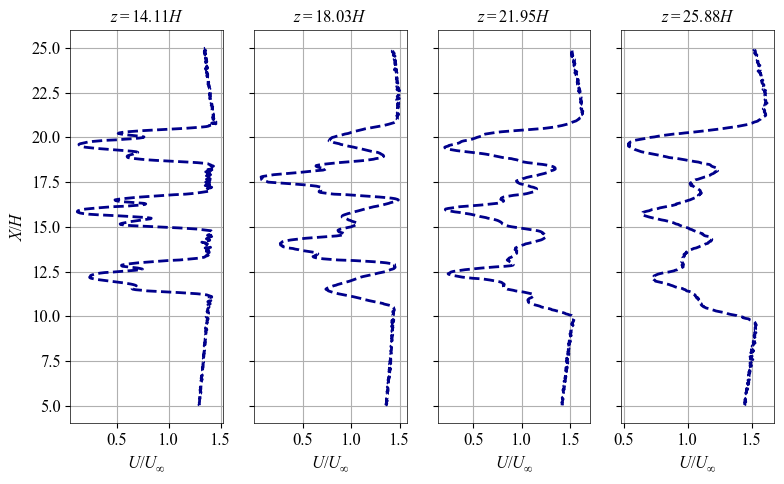

In [209]:
plt.style.use('default')

# Group dataframes you want to plot
line_dfs = {
    'z141065': z141065,
    'z258756': z258756,
    'z1802953': z1802953,
    'z21952565': z21952565,
}

with plt.rc_context({
    "font.size": 12,
    "font.family": "Times New Roman",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
    "mathtext.default": "it"
}):

    fig, axs = plt.subplots(1, 4, figsize=(8, 5))
    ax1, ax2, ax3, ax4 = axs.flatten()

    # 
    # Manual assignment to subplots with X/H filtering (5-25)
    mask1 = (z141065['X'] >= 5) & (z141065['X'] <= 25)
    ax1.plot(z141065.loc[mask1, 'W'], z141065.loc[mask1, 'X'], linestyle='--', linewidth=2, color='darkblue')
    ax1.set_title('$z=14.11H$')
    ax1.set_xlabel('$U/U_{\infty}$')
    ax1.set_ylabel('$X/H$')
    ax1.grid(True)

    mask2 = (z1802953['X'] >= 5) & (z1802953['X'] <= 25)
    ax2.plot(z1802953.loc[mask2, 'W'], z1802953.loc[mask2, 'X'], linestyle='--', linewidth=2, color='darkblue')
    ax2.set_title('$z=18.03H$')
    ax2.set_xlabel('$U/U_{\infty}$')
    ax2.tick_params(axis='y', labelleft=False)
    ax2.grid(True)

    mask3 = (z21952565['X'] >= 5) & (z21952565['X'] <= 25)
    ax3.plot(z21952565.loc[mask3, 'W'], z21952565.loc[mask3, 'X'], linestyle='--', linewidth=2, color='darkblue')
    ax3.set_title('$z=21.95H$')
    ax3.set_xlabel('$U/U_{\infty}$')
    ax3.tick_params(axis='y', labelleft=False)
    ax3.grid(True)

    mask4 = (z258756['X'] >= 5) & (z258756['X'] <= 25)
    ax4.plot(z258756.loc[mask4, 'W'], z258756.loc[mask4, 'X'], linestyle='--', linewidth=2, color='darkblue')
    ax4.set_title('$z=25.88H$')
    ax4.set_xlabel('$U/U_{\infty}$')
    ax4.tick_params(axis='y', labelleft=False)
    ax4.grid(True)

    for ax in (ax1, ax2, ax3, ax4):
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    plt.tight_layout()
    plt.show()

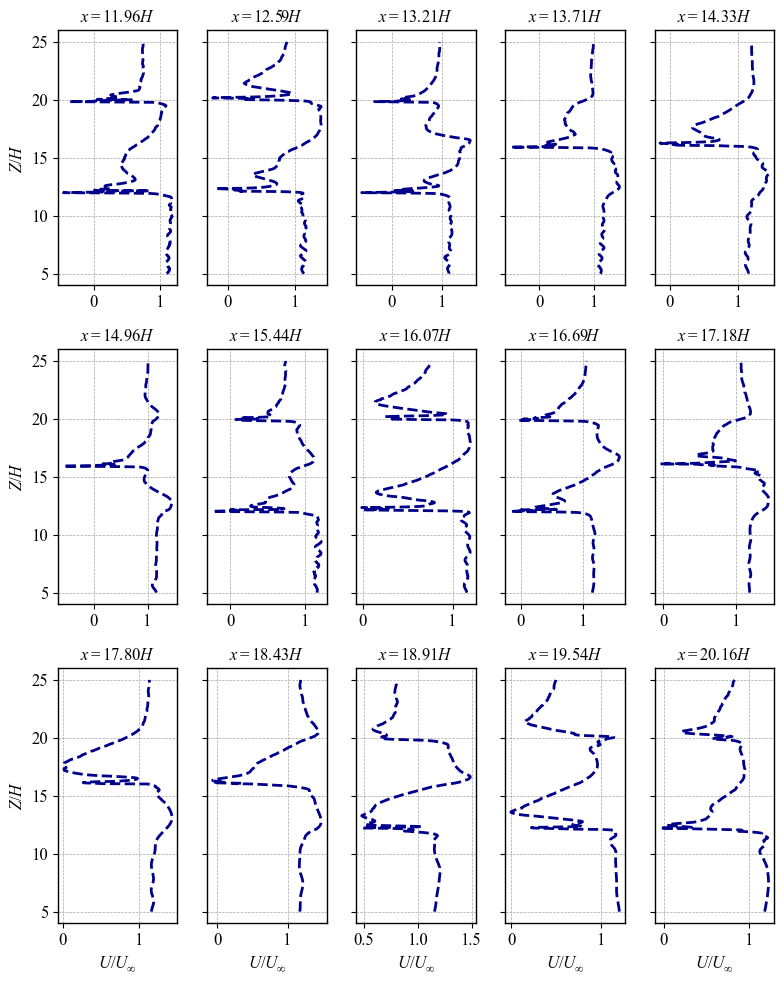

In [213]:
plt.style.use('default')

# Group dataframes you want to plot
line_dfs = {
    'x11964': x11964,
    'x12589': x12589,
    'x13214': x13214,
    'x13708': x13708,
    'x14333': x14333,
    'x14958': x14958,
    'x15443': x15443,
    'x16068': x16068,
    'x16693': x16693,
    'x17178': x17178,
    'x17803': x17803,
    'x18428': x18428,
    'x18914': x18914,
    'x19539': x19539,
    'x20164': x20164
}

with plt.rc_context({
    "font.size": 12,
    "font.family": "Times New Roman",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
    "mathtext.default": "it" # 'rm', 'cal', 'it', 'tt', 'sf', 'bf', 'default', 'bb', 'frak', 'scr'
}):

    fig, axs = plt.subplots(3, 5, figsize=(8, 10))
    ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12, ax13, ax14, ax15 = axs.flatten()

    # 
    # Compute consistent x-axis limits across all dataframes
    all_w_values = []
    for df in [x11964, x12589, x13214, x13708, x14333, x14958, x15443, x16068, x16693, x17178, x17803, x18428, x18914, x19539, x20164]:
        all_w_values.extend(df['W'].values)
    x_min, x_max = min(all_w_values), max(all_w_values)

    # Manual assignment to subplots with Z/H filtering (5-25)
    mask1 = (x11964['Z'] >= 5) & (x11964['Z'] <= 25)
    ax1.plot(x11964.loc[mask1, 'W'], x11964.loc[mask1, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax1.set_title('$x=11.96H$')
    ax1.set_ylabel('$Z/H$')
    #ax1.tick_params(axis='x', labelbottom=False)
    ax1.grid(True)
    ax1.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask2 = (x12589['Z'] >= 5) & (x12589['Z'] <= 25)
    ax2.plot(x12589.loc[mask2, 'W'], x12589.loc[mask2, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax2.set_title('$x=12.59H$')
    ax2.tick_params(axis='y', labelleft=False)
    #ax2.tick_params(axis='x', labelbottom=False)
    ax2.grid(True)
    ax2.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask3 = (x13214['Z'] >= 5) & (x13214['Z'] <= 25)
    ax3.plot(x13214.loc[mask3, 'W'], x13214.loc[mask3, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax3.set_title('$x=13.21H$')
    ax3.tick_params(axis='y', labelleft=False)
    #ax3.tick_params(axis='x', labelbottom=False)
    ax3.grid(True)
    ax3.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask4 = (x13708['Z'] >= 5) & (x13708['Z'] <= 25)
    ax4.plot(x13708.loc[mask4, 'W'], x13708.loc[mask4, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax4.set_title('$x=13.71H$')
    ax4.tick_params(axis='y', labelleft=False)
    #ax4.tick_params(axis='x', labelbottom=False)
    ax4.grid(True)
    ax4.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask5 = (x14333['Z'] >= 5) & (x14333['Z'] <= 25)
    ax5.plot(x14333.loc[mask5, 'W'], x14333.loc[mask5, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax5.set_title('$x=14.33H$')
    ax5.tick_params(axis='y', labelleft=False)
    #ax5.tick_params(axis='x', labelbottom=False)
    ax5.grid(True)
    ax5.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask6 = (x14958['Z'] >= 5) & (x14958['Z'] <= 25)
    ax6.plot(x14958.loc[mask6, 'W'], x14958.loc[mask6, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax6.set_title('$x=14.96H$')
    ax6.set_ylabel('$Z/H$')
    #ax6.tick_params(axis='x', labelbottom=False)
    #ax6.tick_params(axis='y', labelleft=False)
    ax6.grid(True)
    ax6.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask7 = (x15443['Z'] >= 5) & (x15443['Z'] <= 25)
    ax7.plot(x15443.loc[mask7, 'W'], x15443.loc[mask7, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax7.set_title('$x=15.44H$')
    ax7.tick_params(axis='y', labelleft=False)
    #ax7.tick_params(axis='x', labelbottom=False)
    ax7.grid(True)
    ax7.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask8 = (x16068['Z'] >= 5) & (x16068['Z'] <= 25)
    ax8.plot(x16068.loc[mask8, 'W'], x16068.loc[mask8, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax8.set_title('$x=16.07H$')
    ax8.tick_params(axis='y', labelleft=False)
    ax8.grid(True)
    ax8.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask9 = (x16693['Z'] >= 5) & (x16693['Z'] <= 25)
    ax9.plot(x16693.loc[mask9, 'W'], x16693.loc[mask9, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax9.set_title('$x=16.69H$')
    ax9.tick_params(axis='y', labelleft=False)
    ax9.grid(True)
    ax9.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask10 = (x17178['Z'] >= 5) & (x17178['Z'] <= 25)
    ax10.plot(x17178.loc[mask10, 'W'], x17178.loc[mask10, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax10.set_title('$x=17.18H$')
    ax10.tick_params(axis='y', labelleft=False)
    ax10.grid(True)
    ax10.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask11 = (x17803['Z'] >= 5) & (x17803['Z'] <= 25)
    ax11.plot(x17803.loc[mask11, 'W'], x17803.loc[mask11, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax11.set_title('$x=17.80H$')
    ax11.set_xlabel('$U/U_{\infty}$')
    ax11.set_ylabel('$Z/H$')
    #ax11.tick_params(axis='y', labelleft=False)
    ax11.grid(True)
    ax11.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask12 = (x18428['Points:2'] >= 5) & (x18428['Points:2'] <= 25)
    ax12.plot(x18428.loc[mask12, 'W'], x18428.loc[mask12, 'Points:2'], linestyle='--', linewidth=2, color='darkblue')
    ax12.set_title('$x=18.43H$')
    ax12.set_xlabel('$U/U_{\infty}$')
    ax12.tick_params(axis='y', labelleft=False)
    ax12.grid(True)
    ax12.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask13 = (x18914['Z'] >= 5) & (x18914['Z'] <= 25)
    ax13.plot(x18914.loc[mask13, 'W'], x18914.loc[mask13, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax13.set_title('$x=18.91H$')
    ax13.set_xlabel('$U/U_{\infty}$')
    ax13.tick_params(axis='y', labelleft=False)
    ax13.grid(True)
    ax13.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask14 = (x19539['Z'] >= 5) & (x19539['Z'] <= 25)
    ax14.plot(x19539.loc[mask14, 'W'], x19539.loc[mask14, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax14.set_title('$x=19.54H$')
    ax14.set_xlabel('$U/U_{\infty}$')
    ax14.tick_params(axis='y', labelleft=False)
    ax14.grid(True)
    ax14.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask15 = (x20164['Z'] >= 5) & (x20164['Z'] <= 25)
    ax15.plot(x20164.loc[mask15, 'W'], x20164.loc[mask15, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax15.set_title('$x=20.16H$')
    ax15.set_xlabel('$U/U_{\infty}$')
    ax15.tick_params(axis='y', labelleft=False)
    ax15.grid(True)
    ax15.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    for ax in (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12, ax13, ax14, ax15):
        for spine in ax.spines.values():
            spine.set_linewidth(1)

    plt.tight_layout()
    plt.show()

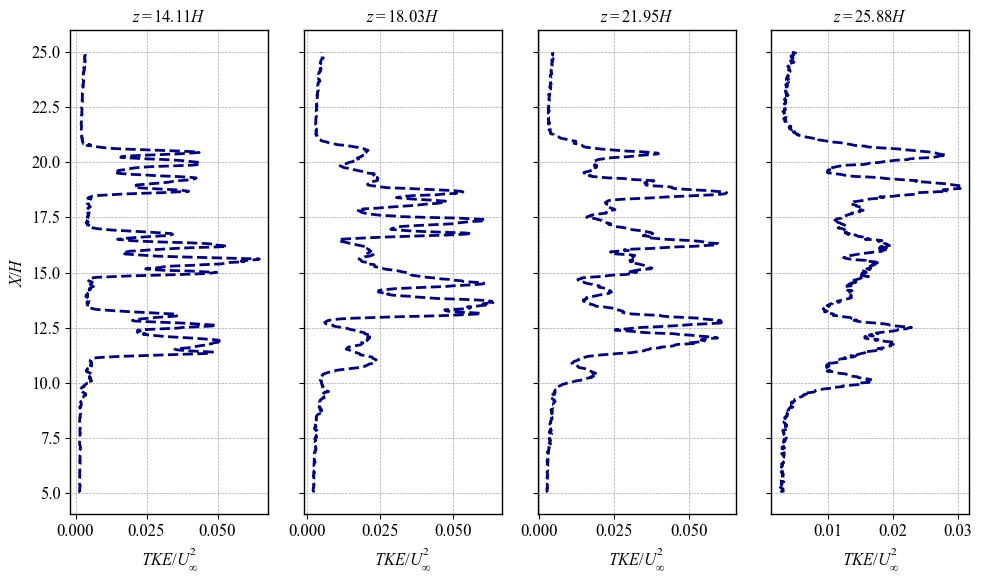

In [214]:
plt.style.use('default')

# Group dataframes you want to plot
line_dfs = {
    'z141065': z141065,
    'z258756': z258756,
    'z1802953': z1802953,
    'z21952565': z21952565,
}

with plt.rc_context({
    "font.size": 12,
    "font.family": "Times New Roman",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
    "mathtext.default": "it"
}):

    fig, axs = plt.subplots(1, 4, figsize=(10, 6))
    ax1, ax2, ax3, ax4 = axs.flatten()

    # 
    # Manual assignment to subplots with X/H filtering (5-25)
    mask1 = (z141065['X'] >= 5) & (z141065['X'] <= 25)
    ax1.plot(z141065.loc[mask1, 'K'], z141065.loc[mask1, 'X'], linestyle='--', linewidth=2, color='darkblue')
    ax1.set_title('$z=14.11H$')
    ax1.set_xlabel('$TKE/U_{\infty}^2$')
    ax1.set_ylabel('$X/H$')
    ax1.grid(True)
    ax1.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask2 = (z1802953['X'] >= 5) & (z1802953['X'] <= 25)
    ax2.plot(z1802953.loc[mask2, 'K'], z1802953.loc[mask2, 'X'], linestyle='--', linewidth=2, color='darkblue')
    ax2.set_title('$z=18.03H$')
    ax2.set_xlabel('$TKE/U_{\infty}^2$')
    ax2.tick_params(axis='y', labelleft=False)
    ax2.grid(True)
    ax2.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask3 = (z21952565['X'] >= 5) & (z21952565['X'] <= 25)
    ax3.plot(z21952565.loc[mask3, 'K'], z21952565.loc[mask3, 'X'], linestyle='--', linewidth=2, color='darkblue')
    ax3.set_title('$z=21.95H$')
    ax3.set_xlabel('$TKE/U_{\infty}^2$')
    ax3.tick_params(axis='y', labelleft=False)
    ax3.grid(True)
    ax3.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask4 = (z258756['X'] >= 5) & (z258756['X'] <= 25)
    ax4.plot(z258756.loc[mask4, 'K'], z258756.loc[mask4, 'X'], linestyle='--', linewidth=2, color='darkblue')
    ax4.set_title('$z=25.88H$')
    ax4.set_xlabel('$TKE/U_{\infty}^2$')
    ax4.tick_params(axis='y', labelleft=False)
    ax4.grid(True)
    ax4.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)


    for ax in (ax1, ax2, ax3, ax4):
        for spine in ax.spines.values():
            spine.set_linewidth(1)

    plt.tight_layout()
    plt.show()

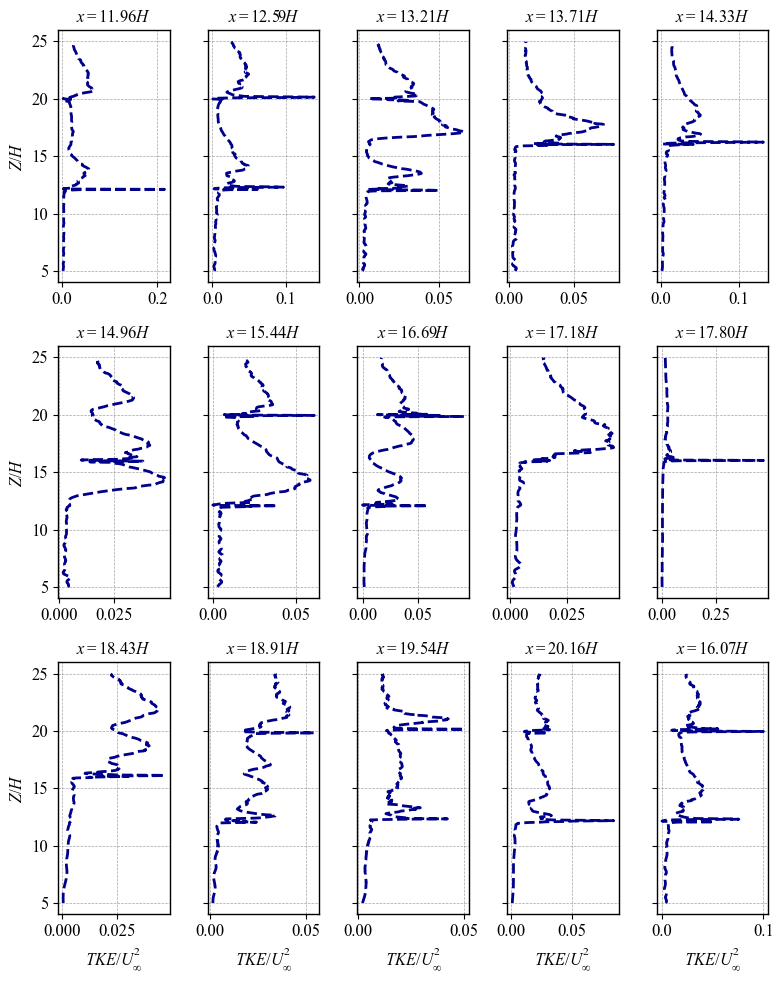

In [215]:
plt.style.use('default')

# Group dataframes you want to plot
line_dfs = {
    'x11964': x11964,
    'x12589': x12589,
    'x13214': x13214,
    'x13708': x13708,
    'x14333': x14333,
    'x14958': x14958,
    'x15443': x15443,
    'x16068': x16068,
    'x16693': x16693,
    'x17178': x17178,
    'x17803': x17803,
    'x18428': x18428,
    'x18914': x18914,
    'x19539': x19539,
    'x20164': x20164
}

with plt.rc_context({
    "font.size": 12,
    "font.family": "Times New Roman",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
    "mathtext.default": "it" # 'rm', 'cal', 'it', 'tt', 'sf', 'bf', 'default', 'bb', 'frak', 'scr'
}):

    fig, axs = plt.subplots(3, 5, figsize=(8, 10))
    ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12, ax13, ax14, ax15 = axs.flatten()

    # 
    # Manual assignment to subplots with Z/H filtering (5-25)
    mask1 = (x11964['Z'] >= 5) & (x11964['Z'] <= 25)
    ax1.plot(x11964.loc[mask1, 'K'], x11964.loc[mask1, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax1.set_title('$x=11.96H$')
    ax1.set_ylabel('$Z/H$')
    #ax1.tick_params(axis='x', labelbottom=False)
    ax1.grid(True)
    ax1.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask2 = (x12589['Z'] >= 5) & (x12589['Z'] <= 25)
    ax2.plot(x12589.loc[mask2, 'K'], x12589.loc[mask2, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax2.set_title('$x=12.59H$')
    ax2.tick_params(axis='y', labelleft=False)
    #ax2.tick_params(axis='x', labelbottom=False)
    ax2.grid(True)
    ax2.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask3 = (x13214['Z'] >= 5) & (x13214['Z'] <= 25)
    ax3.plot(x13214.loc[mask3, 'K'], x13214.loc[mask3, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax3.set_title('$x=13.21H$')
    ax3.tick_params(axis='y', labelleft=False)
    #ax3.tick_params(axis='x', labelbottom=False)
    ax3.grid(True)
    ax3.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask4 = (x13708['Z'] >= 5) & (x13708['Z'] <= 25)
    ax4.plot(x13708.loc[mask4, 'K'], x13708.loc[mask4, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax4.set_title('$x=13.71H$')
    ax4.tick_params(axis='y', labelleft=False)
    #ax4.tick_params(axis='x', labelbottom=False)
    ax4.grid(True)
    ax4.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask5 = (x14333['Z'] >= 5) & (x14333['Z'] <= 25)
    ax5.plot(x14333.loc[mask5, 'K'], x14333.loc[mask5, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax5.set_title('$x=14.33H$')
    ax5.tick_params(axis='y', labelleft=False)
    #ax5.tick_params(axis='x', labelbottom=False)
    ax5.grid(True)
    ax5.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask6 = (x14958['Z'] >= 5) & (x14958['Z'] <= 25)
    ax6.plot(x14958.loc[mask6, 'K'], x14958.loc[mask6, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax6.set_title('$x=14.96H$')
    ax6.set_ylabel('$Z/H$')
    #ax6.tick_params(axis='x', labelbottom=False)
    ax6.grid(True)
    ax6.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask7 = (x15443['Z'] >= 5) & (x15443['Z'] <= 25)
    ax7.plot(x15443.loc[mask7, 'K'], x15443.loc[mask7, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax7.set_title('$x=15.44H$')
    ax7.tick_params(axis='y', labelleft=False)
    #ax7.tick_params(axis='x', labelbottom=False)
    ax7.grid(True)
    ax7.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask8 = (x16693['Z'] >= 5) & (x16693['Z'] <= 25)
    ax8.plot(x16693.loc[mask8, 'K'], x16693.loc[mask8, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax8.set_title('$x=16.69H$')
    ax8.tick_params(axis='y', labelleft=False)
    ax8.grid(True)
    ax8.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask9 = (x17178['Z'] >= 5) & (x17178['Z'] <= 25)
    ax9.plot(x17178.loc[mask9, 'K'], x17178.loc[mask9, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax9.set_title('$x=17.18H$')
    ax9.tick_params(axis='y', labelleft=False)
    ax9.grid(True)
    ax9.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask10 = (x17803['Z'] >= 5) & (x17803['Z'] <= 25)
    ax10.plot(x17803.loc[mask10, 'K'], x17803.loc[mask10, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax10.set_title('$x=17.80H$')
    ax10.tick_params(axis='y', labelleft=False)
    ax10.grid(True)
    ax10.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask11 = (x18428['Points:2'] >= 5) & (x18428['Points:2'] <= 25)
    ax11.plot(x18428.loc[mask11, 'K'], x18428.loc[mask11, 'Points:2'], linestyle='--', linewidth=2, color='darkblue')
    ax11.set_title('$x=18.43H$')
    ax11.set_xlabel('$TKE/U_{\infty}^2$')
    ax11.set_ylabel('$Z/H$')
    ax11.grid(True)
    ax11.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask12 = (x18914['Z'] >= 5) & (x18914['Z'] <= 25)
    ax12.plot(x18914.loc[mask12, 'K'], x18914.loc[mask12, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax12.set_title('$x=18.91H$')
    ax12.set_xlabel('$TKE/U_{\infty}^2$')
    ax12.tick_params(axis='y', labelleft=False)
    ax12.grid(True)
    ax12.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask13 = (x19539['Z'] >= 5) & (x19539['Z'] <= 25)
    ax13.plot(x19539.loc[mask13, 'K'], x19539.loc[mask13, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax13.set_title('$x=19.54H$')
    ax13.set_xlabel('$TKE/U_{\infty}^2$')
    ax13.tick_params(axis='y', labelleft=False)
    ax13.grid(True)
    ax13.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask14 = (x20164['Z'] >= 5) & (x20164['Z'] <= 25)
    ax14.plot(x20164.loc[mask14, 'K'], x20164.loc[mask14, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax14.set_title('$x=20.16H$')
    ax14.set_xlabel('$TKE/U_{\infty}^2$')
    ax14.tick_params(axis='y', labelleft=False)
    ax14.grid(True)
    ax14.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    mask15 = (x16068['Z'] >= 5) & (x16068['Z'] <= 25)
    ax15.plot(x16068.loc[mask15, 'K'], x16068.loc[mask15, 'Z'], linestyle='--', linewidth=2, color='darkblue')
    ax15.set_title('$x=16.07H$')
    ax15.set_xlabel('$TKE/U_{\infty}^2$')
    ax15.tick_params(axis='y', labelleft=False)
    ax15.grid(True)
    ax15.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    for ax in (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12, ax13, ax14, ax15):
        for spine in ax.spines.values():
            spine.set_linewidth(1)

    plt.tight_layout()
    plt.show()